<a href="https://colab.research.google.com/github/m7-code/Models/blob/main/human_face_age_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls -la /content/drive/MyDrive/age_prediction_models/

Mounted at /content/drive
total 63874
-rw------- 1 root root 32697999 Jul  6 11:11 best_model.pth
-rw------- 1 root root 32707343 Jul  6 11:34 checkpoint_20260706_113430.pth
-rw------- 1 root root      185 Jul  6 11:34 metadata_20260706_113430.json


In [ ]:
!pip install -q torchvision tqdm timm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from PIL import Image
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import timm
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
def build_model(dropout=0.4):
    model = timm.create_model('efficientnet_b2', pretrained=False, drop_rate=dropout)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(dropout / 2),
        nn.Linear(256, 1)
    )
    return model.to(device)

model = build_model()

In [ ]:
MODEL_PATH = '/content/drive/MyDrive/age_prediction_models/best_model.pth'
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()
print("Trained model loaded successfully!")

Trained model loaded successfully!


In [ ]:
from google.colab import files
print("Apni kaggle.json upload karo:")
uploaded = files.upload()

!mv face.json kaggle.json
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle datasets list -s "utkface"

Apni kaggle.json upload karo:


Saving face.json to face (1).json
ref                                                     title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
------------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
jangedoo/utkface-new                                    UTKFace                                    347342542  2018-08-16 19:05:30.363000          84922        434  0.6875           
moritzm00/utkface-cropped                               UTKFace (Aligned & Cropped)                121383491  2023-04-16 11:40:42.277000           3550         11  0.75             
ayushkumar0801/utkface-uncropped-dataset                UTKFace Uncropped Dataset                 1396325619  2021-05-16 07:28:58.743000            321          6  0.625            
arashnic/faces-age-detection-dataset                    

In [ ]:
!kaggle datasets download -d abhikjha/imdb-wiki-faces-dataset -p /content/imdb_wiki --unzip

Dataset URL: https://www.kaggle.com/datasets/abhikjha/imdb-wiki-faces-dataset
License(s): unknown
100% 5.92G/5.92G [04:43<00:00, 22.4MB/s]



In [ ]:
!ls -la /content/imdb_wiki

total 12
drwxr-xr-x   3 root root 4096 Jul  8 09:42 .
drwxr-xr-x   1 root root 4096 Jul  8 09:35 ..
drwxr-xr-x 102 root root 4096 Jul  8 09:42 imdb_crop


In [ ]:
!find /content/imdb_wiki -maxdepth 3 -type d

/content/imdb_wiki
/content/imdb_wiki/imdb_crop
/content/imdb_wiki/imdb_crop/30
/content/imdb_wiki/imdb_crop/46
/content/imdb_wiki/imdb_crop/21
/content/imdb_wiki/imdb_crop/48
/content/imdb_wiki/imdb_crop/77
/content/imdb_wiki/imdb_crop/02
/content/imdb_wiki/imdb_crop/88
/content/imdb_wiki/imdb_crop/13
/content/imdb_wiki/imdb_crop/84
/content/imdb_wiki/imdb_crop/81
/content/imdb_wiki/imdb_crop/68
/content/imdb_wiki/imdb_crop/83
/content/imdb_wiki/imdb_crop/06
/content/imdb_wiki/imdb_crop/50
/content/imdb_wiki/imdb_crop/37
/content/imdb_wiki/imdb_crop/01
/content/imdb_wiki/imdb_crop/45
/content/imdb_wiki/imdb_crop/04
/content/imdb_wiki/imdb_crop/89
/content/imdb_wiki/imdb_crop/59
/content/imdb_wiki/imdb_crop/75
/content/imdb_wiki/imdb_crop/25
/content/imdb_wiki/imdb_crop/67
/content/imdb_wiki/imdb_crop/69
/content/imdb_wiki/imdb_crop/73
/content/imdb_wiki/imdb_crop/49
/content/imdb_wiki/imdb_crop/47
/content/imdb_wiki/imdb_crop/32
/content/imdb_wiki/imdb_crop/56
/content/imdb_wiki/imdb_

In [ ]:
!find /content/imdb_wiki -name "*.mat"

/content/imdb_wiki/imdb_crop/imdb.mat


In [ ]:
import scipy.io
from datetime import datetime
import numpy as np

def calc_age(taken, dob):
    birth = datetime.fromordinal(max(int(dob) - 366, 1))
    if birth.month < 7:
        return taken - birth.year
    else:
        return taken - birth.year - 1

mat = scipy.io.loadmat('/content/imdb_wiki/imdb_crop/imdb.mat')
data = mat['imdb'][0, 0]

dob = data['dob'][0]
photo_taken = data['photo_taken'][0]
full_path = data['full_path'][0]
face_score = data['face_score'][0]
second_face_score = data['second_face_score'][0]

ages = np.array([calc_age(photo_taken[i], dob[i]) for i in range(len(dob))])
paths = np.array([p[0] for p in full_path])

print(f"Total entries: {len(ages)}")

/tmp/ipykernel_535/2110134292.py:10: RuntimeWarning: overflow encountered in scalar subtract
  return taken - birth.year - 1
/tmp/ipykernel_535/2110134292.py:8: RuntimeWarning: overflow encountered in scalar subtract
  return taken - birth.year


Total entries: 460723


In [ ]:
# Sirf wo images rakho jinme:
# - face confidently detect hui ho (face_score > 1, -inf nahi)
# - koi doosra face na ho (second_face_score NaN ho)
# - age realistic range mein ho (0-100)

valid_mask = (
    (face_score != -np.inf) &
    (face_score > 1.0) &
    (np.isnan(second_face_score)) &
    (ages >= 0) & (ages <= 100)
)

clean_ages = ages[valid_mask]
clean_paths = paths[valid_mask]

print(f"Clean/valid entries after filtering: {len(clean_ages)} (out of {len(ages)})")

Clean/valid entries after filtering: 174632 (out of 460723)


In [ ]:
import shutil
from pathlib import Path
from collections import defaultdict
import random

random.seed(42)

MAX_PER_AGE = 400   # har age ke liye zyada se zyada itni images rakhni hain

# Age ke hisaab se group karo
age_groups = defaultdict(list)
for path, age in zip(clean_paths, clean_ages):
    age_groups[age].append(path)

# Har age se max MAX_PER_AGE randomly sample karo
sampled = []
for age, paths_list in age_groups.items():
    if len(paths_list) > MAX_PER_AGE:
        paths_list = random.sample(paths_list, MAX_PER_AGE)
    for p in paths_list:
        sampled.append((p, age))

print(f"Total sampled images: {len(sampled)}")

# Output folder banao aur UTKFace jaisi naming se copy karo (age_index.jpg)
OUT_DIR = Path('/content/imdb_wiki_filtered')
OUT_DIR.mkdir(exist_ok=True)

for i, (rel_path, age) in enumerate(sampled):
    src = Path('/content/imdb_wiki/imdb_crop') / rel_path
    dst = OUT_DIR / f"{age}_{i}.jpg"
    if src.exists():
        shutil.copy(src, dst)

print(f"Copied {len(list(OUT_DIR.glob('*.jpg')))} images to {OUT_DIR}")

Total sampled images: 28108
Copied 28108 images to /content/imdb_wiki_filtered


In [ ]:
!zip -r -q /content/imdb_wiki_filtered.zip /content/imdb_wiki_filtered

import shutil
shutil.copy('/content/imdb_wiki_filtered.zip', '/content/drive/MyDrive/imdb_wiki_filtered.zip')

print("Zip Drive pe save ho gayi!")
!ls -la /content/drive/MyDrive/imdb_wiki_filtered.zip

Zip Drive pe save ho gayi!
-rw------- 1 root root 426706316 Jul  8 09:56 /content/drive/MyDrive/imdb_wiki_filtered.zip


In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import torch

class CombinedFaceDataset(Dataset):
    """
    UTKFace format:      age_gender_race_date.jpg
    IMDB-WIKI filtered:  age_index.jpg
    Dono se sirf age nikalta hai (pehla part filename ka)
    """
    def __init__(self, image_paths, transform=None):
        self.transform = transform
        self.images = []
        self.ages = []

        for img_path in image_paths:
            try:
                age = int(img_path.name.split('_')[0])
                if 0 <= age <= 100:
                    self.images.append(img_path)
                    self.ages.append(age)
            except (ValueError, IndexError):
                continue

        print(f"Loaded {len(self.images)} valid images (skipped {len(image_paths) - len(self.images)})")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert('RGB')
        age = torch.tensor(self.ages[idx], dtype=torch.float32)
        if self.transform:
            img = self.transform(img)
        return img, age

In [ ]:
from pathlib import Path

utkface_images = list(Path('/content/utkface/UTKFace').glob('*.jpg'))
imdb_wiki_images = list(Path('/content/imdb_wiki_filtered').glob('*.jpg'))

print(f"UTKFace: {len(utkface_images)}")
print(f"IMDB-WIKI filtered: {len(imdb_wiki_images)}")

all_combined = utkface_images + imdb_wiki_images
print(f"Total combined: {len(all_combined)}")

UTKFace: 0
IMDB-WIKI filtered: 28108
Total combined: 28108


In [ ]:
import zipfile
ZIP_FILE_PATH = '/content/drive/MyDrive/human_face.zip'   # apna path check kar lena
with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
    zip_ref.extractall('/content/utkface')

In [ ]:
utkface_images = list(Path('/content/utkface/UTKFace').glob('*.jpg'))

In [ ]:
!ls /content/utkface

crop_part1  UTKFace  utkface_aligned_cropped


In [ ]:
from pathlib import Path

utkface_images = list(Path('/content/utkface/UTKFace').glob('*.jpg'))
imdb_wiki_images = list(Path('/content/imdb_wiki_filtered').glob('*.jpg'))

print(f"UTKFace: {len(utkface_images)}")
print(f"IMDB-WIKI filtered: {len(imdb_wiki_images)}")

all_combined = utkface_images + imdb_wiki_images
print(f"Total combined: {len(all_combined)}")

UTKFace: 23708
IMDB-WIKI filtered: 28108
Total combined: 51816


In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from torchvision import transforms

train_paths, temp_paths = train_test_split(all_combined, test_size=0.15, random_state=42)
val_paths, test_paths = train_test_split(temp_paths, test_size=0.5, random_state=42)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CombinedFaceDataset(train_paths, transform=train_transform)
val_dataset   = CombinedFaceDataset(val_paths, transform=val_transform)
test_dataset  = CombinedFaceDataset(test_paths, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

Train: 44043 | Val: 3886 | Test: 3887
Loaded 44025 valid images (skipped 18)
Loaded 3885 valid images (skipped 1)
Loaded 3885 valid images (skipped 2)


Model architecture + purana trained weights load

In [ ]:
import timm
import torch.nn as nn
import torch

def build_model(dropout=0.4):
    model = timm.create_model('efficientnet_b2', pretrained=False, drop_rate=dropout)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(dropout / 2),
        nn.Linear(256, 1)
    )
    return model.to(device)

model = build_model()
model.load_state_dict(torch.load('/content/drive/MyDrive/age_prediction_models/best_model.pth', map_location=device))
print("Purana trained model loaded, fine-tuning ke liye ready")

Purana trained model loaded, fine-tuning ke liye ready


**Fine-tuning setup**

In [ ]:
import torch.optim as optim

criterion = nn.L1Loss()

# Fine-tuning ke liye learning rate bahut kam rakhte hain (original training se 5-10x chota)
# taake purana seekha hua knowledge kharab na ho, bas naye data ka thoda adjustment ho
FT_LEARNING_RATE = 0.00002
NUM_EPOCHS = 10

optimizer = optim.AdamW(model.parameters(), lr=FT_LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc="Training")
    for images, ages in pbar:
        images, ages = images.to(device), ages.to(device).unsqueeze(1)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, ages)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        pbar.set_postfix({'MAE': f'{loss.item():.2f}'})
    return running_loss / len(dataloader.dataset)

def validate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_true = [], []
    with torch.no_grad():
        for images, ages in tqdm(dataloader, desc="Validating"):
            images, ages = images.to(device), ages.to(device).unsqueeze(1)
            outputs = model(images)
            loss = criterion(outputs, ages)
            running_loss += loss.item() * images.size(0)
            all_preds.extend(outputs.cpu().numpy().flatten())
            all_true.extend(ages.cpu().numpy().flatten())
    return running_loss / len(dataloader.dataset), all_preds, all_true

Fine-tuning loop

In [ ]:
from pathlib import Path

history_ft = {'train_mae': [], 'val_mae': []}
best_val_mae_ft = float('inf')

PATIENCE = 4
patience_counter = 0

SAVE_DIR = Path('/content/drive/MyDrive/age_prediction_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("FINE-TUNING STARTED")
print("=" * 60)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 60)

    train_mae = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_mae, _, _ = validate(model, val_loader, criterion, device)
    scheduler.step()

    history_ft['train_mae'].append(train_mae)
    history_ft['val_mae'].append(val_mae)

    print(f"Train MAE: {train_mae:.2f} years | Val MAE: {val_mae:.2f} years")

    if val_mae < best_val_mae_ft:
        best_val_mae_ft = val_mae
        patience_counter = 0
        torch.save(model.state_dict(), SAVE_DIR / 'best_model_finetuned.pth')
        print(f"Best fine-tuned model saved! (Val MAE: {val_mae:.2f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("Early stopping triggered!")
            break

print("\n" + "=" * 60)
print(f"FINE-TUNING COMPLETE. Best Val MAE: {best_val_mae_ft:.2f} years")
print("=" * 60)

FINE-TUNING STARTED

Epoch 1/10
------------------------------------------------------------


Validating: 100%|██████████| 122/122 [00:13<00:00,  9.20it/s]


Train MAE: 7.91 years | Val MAE: 7.17 years
Best fine-tuned model saved! (Val MAE: 7.17)

Epoch 2/10
------------------------------------------------------------


Validating: 100%|██████████| 122/122 [00:12<00:00,  9.78it/s]


Train MAE: 7.01 years | Val MAE: 6.77 years
Best fine-tuned model saved! (Val MAE: 6.77)

Epoch 3/10
------------------------------------------------------------


...

Train MAE: 5.72 years | Val MAE: 6.47 years
No improvement. Patience: 2/4

Epoch 9/10
------------------------------------------------------------


Validating: 100%|██████████| 122/122 [00:13<00:00,  9.06it/s]


Train MAE: 5.67 years | Val MAE: 6.45 years
No improvement. Patience: 3/4

Epoch 10/10
------------------------------------------------------------


Validating: 100%|██████████| 122/122 [00:12<00:00,  9.53it/s]


Train MAE: 5.63 years | Val MAE: 6.42 years
Best fine-tuned model saved! (Val MAE: 6.42)

FINE-TUNING COMPLETE. Best Val MAE: 6.42 years


In [ ]:
# UTKFace-only test set banao (sirf UTKFace images se)
utkface_test_only = [p for p in test_paths if 'UTKFace' in str(p) or p.parent.name == 'UTKFace']
print(f"UTKFace-only test images: {len(utkface_test_only)}")

utkface_test_dataset = CombinedFaceDataset(utkface_test_only, transform=val_transform)
utkface_test_loader = DataLoader(utkface_test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Purana model load karo
old_model = build_model()
old_model.load_state_dict(torch.load('/content/drive/MyDrive/age_prediction_models/best_model.pth', map_location=device))
old_model.eval()

# Naya (fine-tuned) model load karo
new_model = build_model()
new_model.load_state_dict(torch.load('/content/drive/MyDrive/age_prediction_models/best_model_finetuned.pth', map_location=device))
new_model.eval()

old_mae, _, _ = validate(old_model, utkface_test_loader, criterion, device)
new_mae, _, _ = validate(new_model, utkface_test_loader, criterion, device)

print(f"\nOLD model on UTKFace test: {old_mae:.2f} years")
print(f"NEW (fine-tuned) model on UTKFace test: {new_mae:.2f} years")

UTKFace-only test images: 1768
Loaded 1766 valid images (skipped 2)


Validating: 100%|██████████| 56/56 [00:05<00:00,  9.55it/s]


OLD model on UTKFace test: 3.16 years
NEW (fine-tuned) model on UTKFace test: 3.42 years


In [ ]:
!pip install -q opencv-python
import cv2
from PIL import Image

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

def detect_and_crop_face(image_path, margin=0.3):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

    if len(faces) == 0:
        print("Koi face detect nahi hua, poori image use kar raha hoon")
        return Image.open(image_path).convert('RGB')

    x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
    mx, my = int(w * margin), int(h * margin)
    x1, y1 = max(0, x - mx), max(0, y - my)
    x2, y2 = min(img.shape[1], x + w + mx), min(img.shape[0], y + h + my)

    cropped = img[y1:y2, x1:x2]
    cropped_rgb = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    return Image.fromarray(cropped_rgb)

In [ ]:
def predict_age_v2(model, image_path, device):
    face_img = detect_and_crop_face(image_path)
    tensor = val_transform(face_img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(tensor).item()
    print(f"Predicted Age: {pred:.1f} years")
    return pred

uploaded = files.upload()
for filename in uploaded.keys():
    print("--- OLD model ---")
    predict_age_v2(old_model, filename, device)
    print("--- NEW (fine-tuned) model ---")
    predict_age_v2(new_model, filename, device)

Saving marina-abrosimova-r8LmVbUKgns-unsplash (1).jpg to marina-abrosimova-r8LmVbUKgns-unsplash (1) (1).jpg
--- OLD model ---
Predicted Age: 11.7 years
--- NEW (fine-tuned) model ---
Predicted Age: 10.3 years


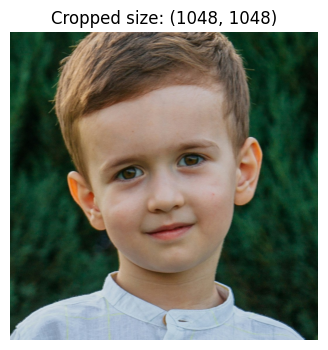

In [ ]:
face_img = detect_and_crop_face('marina-abrosimova-r8LmVbUKgns-unsplash (1) (1).jpg')

import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.imshow(face_img)
plt.axis('off')
plt.title(f"Cropped size: {face_img.size}")
plt.show()

In [ ]:
import cv2
img = cv2.imread('marina-abrosimova-r8LmVbUKgns-unsplash (1) (1).jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
print(f"Faces detected: {len(faces)}")
print(faces)

Faces detected: 17
[[1366  765   74   74]
 [ 282  151   83   83]
 [ 865  843   77   77]
 [1049  667  143  143]
 [ 291  177  103  103]
 [1024  487  112  112]
 [3488 1301  143  143]
 [ 783 1614  149  149]
 [1816 1341  656  656]
 [2391 2335  125  125]
 [ 105 2967   75   75]
 [2544 2864  254  254]
 [1461 3495   73   73]
 [ 481 3656   81   81]
 [1328 3984   73   73]
 [3480 4066  115  115]
 [1515 4328   94   94]]


In [ ]:
import timm
import torch
import torch.nn as nn
from pathlib import Path

def build_model(dropout=0.4):
    model = timm.create_model('efficientnet_b2', pretrained=False, drop_rate=dropout)
    num_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_features, 256),
        nn.ReLU(),
        nn.Dropout(dropout / 2),
        nn.Linear(256, 1)
    )
    return model.to(device)

SAVE_DIR = Path('/content/drive/MyDrive/age_prediction_models')

# Purana model
old_model = build_model()
old_model.load_state_dict(torch.load(SAVE_DIR / 'best_model.pth', map_location=device))
old_model.eval()

# Fine-tuned model
new_model = build_model()
new_model.load_state_dict(torch.load(SAVE_DIR / 'best_model_finetuned.pth', map_location=device))
new_model.eval()

print("Dono models loaded!")

Dono models loaded!


Saving charlie-green-3JmfENcL24M-unsplash.jpg to charlie-green-3JmfENcL24M-unsplash.jpg


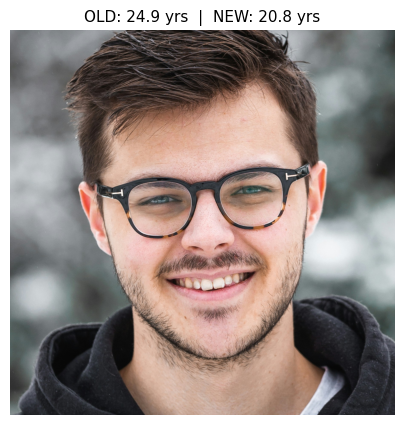

File: charlie-green-3JmfENcL24M-unsplash.jpg
  Old model:        24.9 years
  Fine-tuned model: 20.8 years
--------------------------------------------------


In [ ]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    face_img = detect_and_crop_face(filename)
    tensor = val_transform(face_img).unsqueeze(0).to(device)

    with torch.no_grad():
        old_pred = old_model(tensor).item()
        new_pred = new_model(tensor).item()

    plt.figure(figsize=(5, 5))
    plt.imshow(face_img)
    plt.axis('off')
    plt.title(f"OLD: {old_pred:.1f} yrs  |  NEW: {new_pred:.1f} yrs", fontsize=11)
    plt.show()

    print(f"File: {filename}")
    print(f"  Old model:        {old_pred:.1f} years")
    print(f"  Fine-tuned model: {new_pred:.1f} years")
    print("-" * 50)

In [ ]:
from datetime import datetime
import json

def save_model(model, name, extra_info=None):
    SAVE_DIR = Path('/content/drive/MyDrive/age_prediction_models')
    SAVE_DIR.mkdir(parents=True, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    save_path = SAVE_DIR / f'{name}.pth'
    torch.save(model.state_dict(), save_path)

    metadata = {'model': 'efficientnet_b2', 'saved_at': timestamp}
    if extra_info:
        metadata.update(extra_info)

    with open(SAVE_DIR / f'{name}_metadata_{timestamp}.json', 'w') as f:
        json.dump(metadata, f, indent=2)

    print(f"Saved: {save_path}")

# Example usage:
# save_model(new_model, 'best_model_finetuned_v2', {'val_mae': 6.42})

In [ ]:
files.download(str(SAVE_DIR / 'best_model_finetuned.pth'))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install -q deepface tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 89.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.1 MB/s eta 0:00:00


26-07-08 11:48:53 - Directory /root/.deepface has been created
26-07-08 11:48:53 - Directory /root/.deepface/weights has been created


Saving marina-abrosimova-r8LmVbUKgns-unsplash (1).jpg to marina-abrosimova-r8LmVbUKgns-unsplash (1) (2).jpg
26-07-08 11:49:53 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5
100%|██████████| 539M/539M [00:02<00:00, 194MB/s]


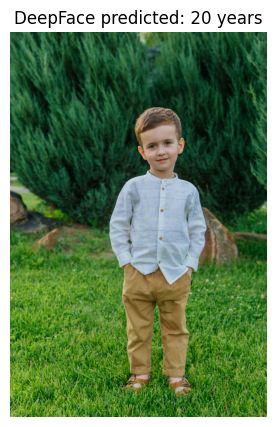

File: marina-abrosimova-r8LmVbUKgns-unsplash (1) (2).jpg -> DeepFace Age: 20


In [ ]:
from deepface import DeepFace
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

uploaded = files.upload()

for filename in uploaded.keys():
    try:
        result = DeepFace.analyze(img_path=filename, actions=['age'], enforce_detection=False)
        deepface_age = result[0]['age']

        img = Image.open(filename)
        plt.figure(figsize=(5, 5))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"DeepFace predicted: {deepface_age} years", fontsize=12)
        plt.show()

        print(f"File: {filename} -> DeepFace Age: {deepface_age}")
    except Exception as e:
        print(f"Error on {filename}: {e}")

Saving marina-abrosimova-r8LmVbUKgns-unsplash (1).jpg to marina-abrosimova-r8LmVbUKgns-unsplash (1) (3).jpg


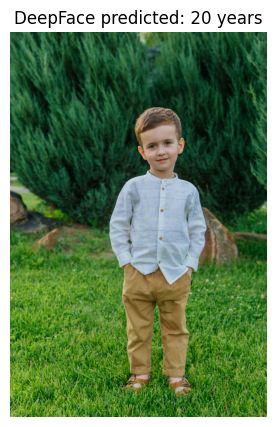

File: marina-abrosimova-r8LmVbUKgns-unsplash (1) (3).jpg -> DeepFace Age: 20


In [ ]:
uploaded = files.upload()

for filename in uploaded.keys():
    result = DeepFace.analyze(img_path=filename, actions=['age'], enforce_detection=False)
    deepface_age = result[0]['age']

    img = Image.open(filename)
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"DeepFace predicted: {deepface_age} years", fontsize=12)
    plt.show()

    print(f"File: {filename} -> DeepFace Age: {deepface_age}")

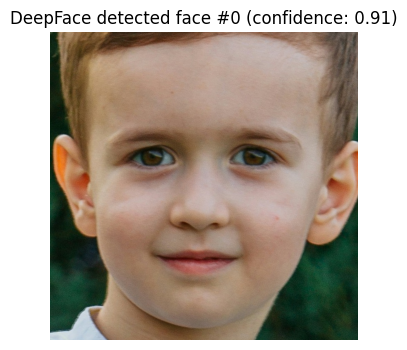

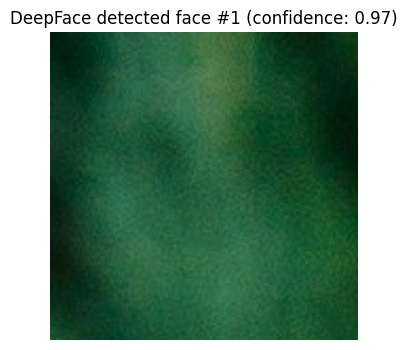

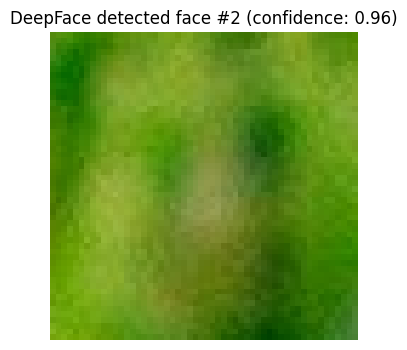

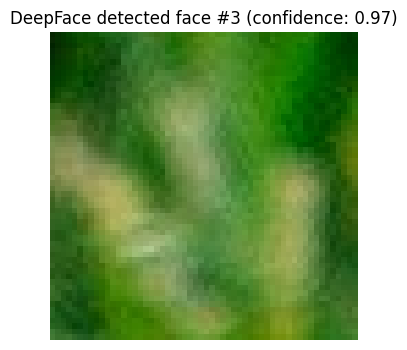

In [ ]:
from deepface import DeepFace
import matplotlib.pyplot as plt

face_objs = DeepFace.extract_faces(img_path=filename, enforce_detection=False)

for i, face_obj in enumerate(face_objs):
    plt.figure(figsize=(4, 4))
    plt.imshow(face_obj['face'])
    plt.axis('off')
    plt.title(f"DeepFace detected face #{i} (confidence: {face_obj['confidence']:.2f})")
    plt.show()

26-07-08 12:00:24 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 282MB/s] 


DeepFace (RetinaFace detector) Age: 21


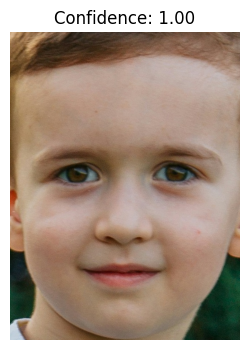

In [ ]:
!pip install -q retina-face

result = DeepFace.analyze(
    img_path=filename,
    actions=['age'],
    enforce_detection=False,
    detector_backend='retinaface'
)

deepface_age = result[0]['age']
print(f"DeepFace (RetinaFace detector) Age: {deepface_age}")

# Face crop bhi dekho verify karne ke liye
face_objs = DeepFace.extract_faces(img_path=filename, enforce_detection=False, detector_backend='retinaface')
plt.figure(figsize=(4, 4))
plt.imshow(face_objs[0]['face'])
plt.axis('off')
plt.title(f"Confidence: {face_objs[0]['confidence']:.2f}")
plt.show()

Saving charlie-green-3JmfENcL24M-unsplash.jpg to charlie-green-3JmfENcL24M-unsplash (1).jpg
DeepFace (RetinaFace) Age: 29


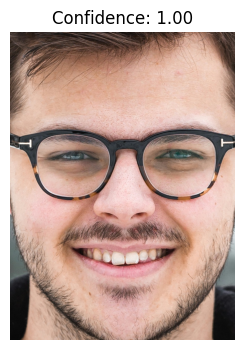

In [ ]:
uploaded = files.upload()

for filename in uploaded.keys():
    result = DeepFace.analyze(
        img_path=filename,
        actions=['age'],
        enforce_detection=False,
        detector_backend='retinaface'
    )
    print(f"DeepFace (RetinaFace) Age: {result[0]['age']}")

    face_objs = DeepFace.extract_faces(img_path=filename, enforce_detection=False, detector_backend='retinaface')
    plt.figure(figsize=(4, 4))
    plt.imshow(face_objs[0]['face'])
    plt.axis('off')
    plt.title(f"Confidence: {face_objs[0]['confidence']:.2f}")
    plt.show()

Saving christopher-campbell-rDEOVtE7vOs-unsplash.jpg to christopher-campbell-rDEOVtE7vOs-unsplash (1).jpg
DeepFace (RetinaFace) Age: 27


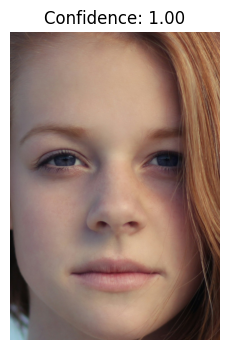

In [ ]:
uploaded = files.upload()

for filename in uploaded.keys():
    result = DeepFace.analyze(
        img_path=filename,
        actions=['age'],
        enforce_detection=False,
        detector_backend='retinaface'
    )
    print(f"DeepFace (RetinaFace) Age: {result[0]['age']}")

    face_objs = DeepFace.extract_faces(img_path=filename, enforce_detection=False, detector_backend='retinaface')
    plt.figure(figsize=(4, 4))
    plt.imshow(face_objs[0]['face'])
    plt.axis('off')
    plt.title(f"Confidence: {face_objs[0]['confidence']:.2f}")
    plt.show()

**MiVOLO**

In [1]:
!git clone https://github.com/WildChlamydia/MiVOLO.git
%cd MiVOLO
!pip install -q -r requirements.txt
!pip install -q -e .
!pip install -q gdown

Cloning into 'MiVOLO'...
remote: Enumerating objects: 286, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 286 (delta 75), reused 51 (delta 48), pack-reused 175 (from 1)
Receiving objects: 100% (286/286), 1.08 MiB | 12.88 MiB/s, done.
Resolving deltas: 100% (153/153), done.
/content/MiVOLO
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.8/183.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.2/699.2 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 3.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [5]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [6]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

from transformers import AutoModelForImageClassification, AutoConfig, AutoImageProcessor

config = AutoConfig.from_pretrained("iitolstykh/mivolo_v2", trust_remote_code=True)
mivolo_model = AutoModelForImageClassification.from_pretrained(
    "iitolstykh/mivolo_v2", trust_remote_code=True, torch_dtype=torch.float16
).to(device)
image_processor = AutoImageProcessor.from_pretrained("iitolstykh/mivolo_v2", trust_remote_code=True)

print("MiVOLO v2 loaded!")

Device: cuda


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/96.0 [00:00<?, ?B/s]

mivolo_image_processor.py:   0%|          | 0.00/1.51k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/iitolstykh/mivolo_v2:
- mivolo_image_processor.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


MiVOLO v2 loaded!


In [8]:
!pip install -q deepface tf-keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.8 MB/s eta 0:00:00


26-07-09 06:35:51 - Directory /root/.deepface has been created
26-07-09 06:35:51 - Directory /root/.deepface/weights has been created


Saving marina-abrosimova-r8LmVbUKgns-unsplash (1).jpg to marina-abrosimova-r8LmVbUKgns-unsplash (1).jpg
26-07-09 06:36:16 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5
100%|██████████| 119M/119M [00:00<00:00, 194MB/s]


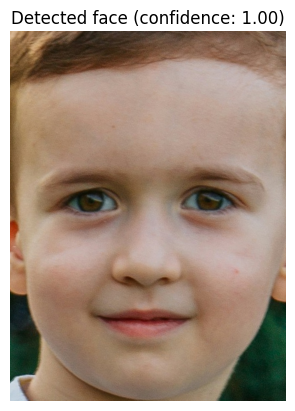

In [9]:
from deepface import DeepFace
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

uploaded = files.upload()
test_image = list(uploaded.keys())[0]

face_objs = DeepFace.extract_faces(img_path=test_image, enforce_detection=False, detector_backend='retinaface')
face_crop = (face_objs[0]['face'] * 255).astype(np.uint8)

plt.imshow(face_crop)
plt.axis('off')
plt.title(f"Detected face (confidence: {face_objs[0]['confidence']:.2f})")
plt.show()

In [12]:
bodies_crops = [face_crop_bgr]  # face ko hi dono jagah use karo agar body None allow na ho
body_input = image_processor(images=bodies_crops)["pixel_values"]
body_input = body_input.to(dtype=mivolo_model.dtype, device=mivolo_model.device)

output = mivolo_model(faces_input=faces_input, body_input=body_input)

In [13]:
import cv2
import torch

# RGB -> BGR
face_crop_bgr = cv2.cvtColor(face_crop, cv2.COLOR_RGB2BGR)

faces_crops = [face_crop_bgr]
bodies_crops = [None]   # humare paas body crop nahi hai, sirf face

faces_input = image_processor(images=faces_crops)["pixel_values"]
faces_input = faces_input.to(dtype=mivolo_model.dtype, device=mivolo_model.device)

# Agar body None hai to body_input bhi None rakhte hain
body_input = None

with torch.no_grad():
    output = mivolo_model(faces_input=faces_input, body_input=body_input)

age = output.age_output[0].item()
print(f"Predicted Age: {round(age, 2)} years")

id2label = config.gender_id2label
gender = id2label[output.gender_class_idx[0].item()]
gender_prob = output.gender_probs[0].item()
print(f"Gender: {gender} [{int(gender_prob * 100)}%]")

TypeError: expected Tensor as element 1 in argument 0, but got NoneType

In [14]:
import cv2
from PIL import Image
import numpy as np
import torch

# Original poori image load karo (body context ke liye)
original_img = np.array(Image.open(test_image).convert('RGB'))
original_img_bgr = cv2.cvtColor(original_img, cv2.COLOR_RGB2BGR)

faces_crops = [face_crop_bgr]
bodies_crops = [original_img_bgr]

faces_input = image_processor(images=faces_crops)["pixel_values"]
faces_input = faces_input.to(dtype=mivolo_model.dtype, device=mivolo_model.device)

body_input = image_processor(images=bodies_crops)["pixel_values"]
body_input = body_input.to(dtype=mivolo_model.dtype, device=mivolo_model.device)

with torch.no_grad():
    output = mivolo_model(faces_input=faces_input, body_input=body_input)

age = output.age_output[0].item()
print(f"Predicted Age: {round(age, 2)} years")

id2label = config.gender_id2label
gender = id2label[output.gender_class_idx[0].item()]
gender_prob = output.gender_probs[0].item()
print(f"Gender: {gender} [{int(gender_prob * 100)}%]")

Predicted Age: 4.84 years
Gender: male [99%]


Saving marina-abrosimova-r8LmVbUKgns-unsplash.jpg to marina-abrosimova-r8LmVbUKgns-unsplash.jpg


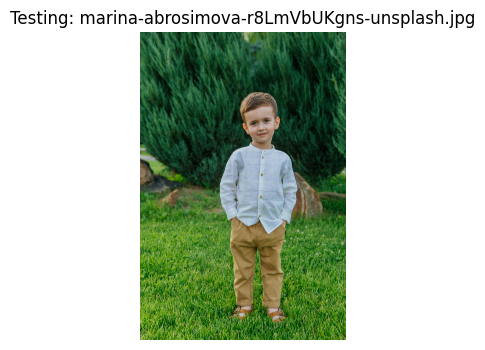

Predicted Age: 5.19 years
Gender: male [99%]


In [22]:
import numpy as np
from PIL import Image
import torch
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
test_image = list(uploaded.keys())[0]

# Pehle image dikhao confirm karne ke liye
img_display = Image.open(test_image)
plt.figure(figsize=(4,4))
plt.imshow(img_display)
plt.axis('off')
plt.title(f"Testing: {test_image}")
plt.show()

# Face detect
face_objs = DeepFace.extract_faces(img_path=test_image, enforce_detection=False, detector_backend='retinaface')
face_crop = (face_objs[0]['face'] * 255).astype(np.uint8)

original_img_rgb = np.array(img_display.convert('RGB'))

faces_input = image_processor(images=[face_crop])["pixel_values"].to(dtype=mivolo_model.dtype, device=mivolo_model.device)
body_input = image_processor(images=[original_img_rgb])["pixel_values"].to(dtype=mivolo_model.dtype, device=mivolo_model.device)

with torch.no_grad():
    output = mivolo_model(faces_input=faces_input, body_input=body_input)

age = output.age_output[0].item()
gender = config.gender_id2label[output.gender_class_idx[0].item()]
gender_prob = output.gender_probs[0].item()

print(f"Predicted Age: {round(age, 2)} years")
print(f"Gender: {gender} [{int(gender_prob * 100)}%]")

In [16]:
def predict_age_gender(image_path):
    img = Image.open(image_path).convert('RGB')
    original_img_rgb = np.array(img)

    face_objs = DeepFace.extract_faces(img_path=image_path, enforce_detection=False, detector_backend='retinaface')
    face_crop = (face_objs[0]['face'] * 255).astype(np.uint8)

    faces_input = image_processor(images=[face_crop])["pixel_values"].to(dtype=mivolo_model.dtype, device=mivolo_model.device)
    body_input = image_processor(images=[original_img_rgb])["pixel_values"].to(dtype=mivolo_model.dtype, device=mivolo_model.device)

    with torch.no_grad():
        output = mivolo_model(faces_input=faces_input, body_input=body_input)

    age = round(output.age_output[0].item(), 1)
    gender = config.gender_id2label[output.gender_class_idx[0].item()]
    gender_prob = int(output.gender_probs[0].item() * 100)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Age: {age} | Gender: {gender} ({gender_prob}%)")
    plt.show()

    return age, gender

# Usage:
# uploaded = files.upload()
# predict_age_gender(list(uploaded.keys())[0])